In [222]:
import pandas as pd
import numpy as np

df = pd.read_csv("hr_attrition_dataset_100k.csv")
df.head()

,employee_id,age,gender,department,job_role,education_field,salary,years_at_company,job_satisfaction,work_life_balance,training_hours,performance_rating,distance_from_home_km,overtime,attrition
0,100000,59,Female,Marketing,HR Manager,Medical,57912.0,35,3.0,1.0,58.0,2,9,No,No
1,100001,49,Other,Sales,Accountant,Medical,76384.0,16,1.0,1.0,17.0,2,30,no,No
2,100002,35,Other,Marketing,Operations Manager,Life Sciences,68578.0,35,4.0,1.0,55.0,1,48,no,No
3,100003,28,Female,Human Resources,Accountant,Technical Degree,81456.0,18,2.0,2.0,9.0,4,28,yes,Yes
4,100004,41,Male,Sales,Operations Manager,Technical Degree,84070.0,3,1.0,3.0,54.0,2,7,yes,No


In [223]:
"""df.shape"""
"""df.columns"""
"""df.info"""
df.describe

<bound method NDFrame.describe of         employee_id  age  gender       department              job_role  \
0            100000   59  Female        Marketing            HR Manager   
1            100001   49   Other            Sales            Accountant   
2            100002   35   Other        Marketing    Operations Manager   
3            100003   28  Female  Human Resources            Accountant   
4            100004   41    Male            Sales    Operations Manager   
...             ...  ...     ...              ...                   ...   
101995       134221   44  Female          Finance    Research Scientist   
101996       145038   36    Male  Human Resources  Marketing Specialist   
101997       188346   46  Female          Finance       Sales Executive   
101998       104405   47    Male        Marketing    Research Scientist   
101999       153039   55   Other       Operations    Research Scientist   

         education_field   salary  years_at_company  job_satisfac

In [224]:
df.isnull().sum()

employee_id                 0
age                         0
gender                      0
department                  0
job_role                    0
education_field             0
salary                   3057
years_at_company            0
job_satisfaction         3061
work_life_balance        3056
training_hours           3061
performance_rating          0
distance_from_home_km       0
overtime                    0
attrition                   0
dtype: int64

In [225]:
df.duplicated().sum()

np.int64(2000)

In [226]:
"""delet all duplicates"""
df.drop_duplicates(inplace=True)

In [227]:
df.duplicated().sum()

np.int64(0)

In [228]:
"""Handling Null Values"""

df['salary'] = df['salary'].fillna(df['salary'].mean())

df['job_satisfaction'] = df['job_satisfaction'].fillna(df['job_satisfaction'].mean())

df['work_life_balance'] = df['work_life_balance'].fillna(df['work_life_balance'].mean())

df['training_hours'] = df['training_hours'].fillna(df['training_hours'].mean())

df.isnull().sum()

employee_id              0
age                      0
gender                   0
department               0
job_role                 0
education_field          0
salary                   0
years_at_company         0
job_satisfaction         0
work_life_balance        0
training_hours           0
performance_rating       0
distance_from_home_km    0
overtime                 0
attrition                0
dtype: int64

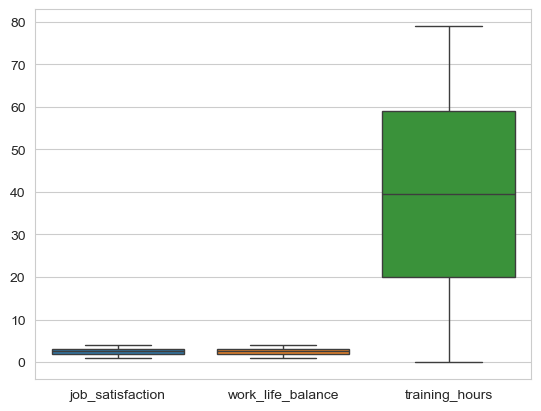

In [229]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['job_satisfaction','work_life_balance','training_hours']])
plt.show()

In [230]:
"""df[['job_satisfaction','work_life_balance','training_hours']].describe()"""

Q1 = df['training_hours'].quantile(0.25)
Q3 = df['training_hours'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['training_hours'] = df['training_hours'].clip(lower, upper)

In [231]:
columns = ['job_satisfaction','work_life_balance','training_hours']

for col in columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)

    

In [232]:

df['job_satisfaction'].max()
df['work_life_balance'].max()
df['training_hours'].max()

79.0

In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

clean_df = pd.read_csv("clean_hr_attrition_dataset_12.csv")
clean_df.head()

,employee_id,age,gender,department,job_role,education_field,salary,years_at_company,job_satisfaction,work_life_balance,training_hours,performance_rating,distance_from_home_km,overtime,attrition
0,100000,59,Female,Marketing,HR Manager,Medical,57912.0,35,3,1,58,2,9,No,No
1,100001,49,Other,Sales,Accountant,Medical,76384.0,16,1,1,17,2,30,no,No
2,100002,35,Other,Marketing,Operations Manager,Life Sciences,68578.0,35,4,1,55,1,48,no,No
3,100003,28,Female,Human Resources,Accountant,Technical Degree,81456.0,18,2,2,9,4,28,yes,Yes
4,100004,41,Male,Sales,Operations Manager,Technical Degree,84070.0,3,1,3,54,2,7,yes,No


In [234]:
clean_df.describe()

,employee_id,age,salary,years_at_company,job_satisfaction,work_life_balance,training_hours,performance_rating,distance_from_home_km
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,149999.500000,40.058210,65010.888577,19.511980,2.483010,2.48149,39.427950,2.503590,24.902260
std,28867.657797,11.243079,19725.346499,11.549876,1.103668,1.10700,22.766984,1.118302,14.147517
min,100000.000000,21.000000,-20027.000000,0.000000,1.000000,1.00000,0.000000,1.000000,1.000000
25%,124999.750000,30.000000,51985.750000,9.000000,2.000000,2.00000,20.000000,2.000000,13.000000
50%,149999.500000,40.000000,65010.888580,20.000000,2.000000,2.00000,39.000000,3.000000,25.000000
75%,174999.250000,50.000000,78006.250000,30.000000,3.000000,3.00000,59.000000,4.000000,37.000000
max,199999.000000,59.000000,143363.000000,39.000000,4.000000,4.00000,79.000000,4.000000,49.000000


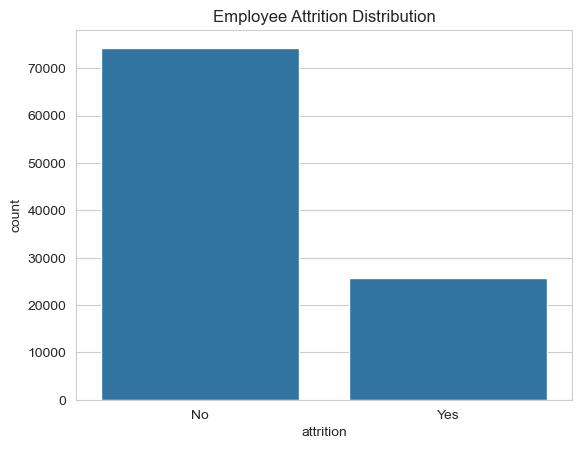

In [235]:
sns.countplot(x="attrition", data=clean_df)
plt.title("Employee Attrition Distribution")
plt.show()

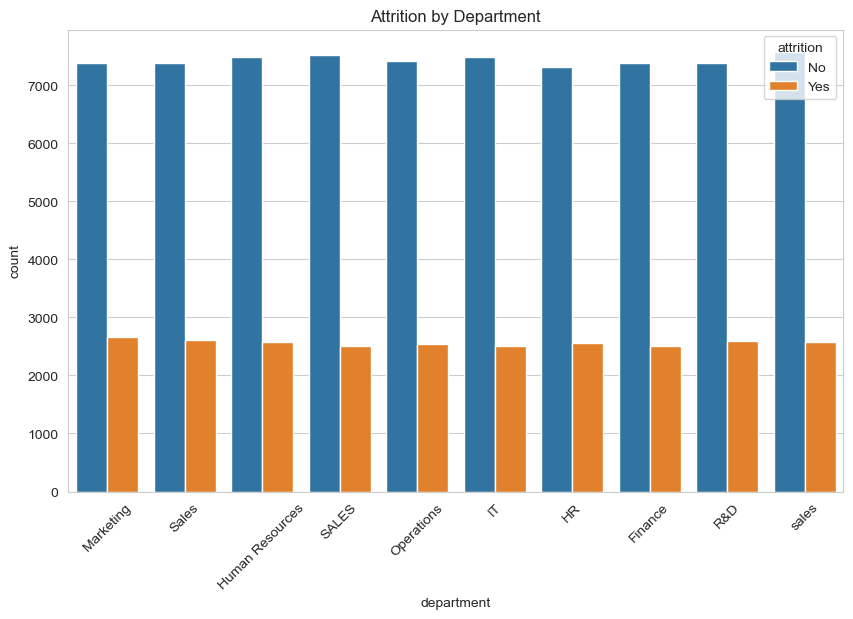

In [236]:
plt.figure(figsize=(10,6))
sns.countplot(x="department", hue="attrition", data=clean_df)
plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()

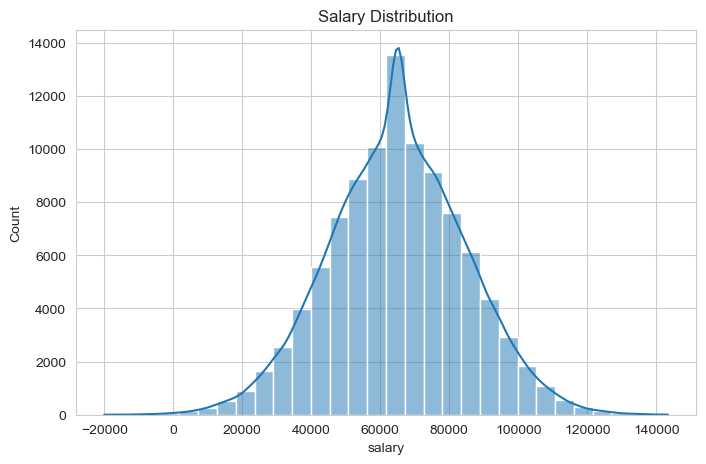

In [237]:
plt.figure(figsize=(8,5))

sns.histplot(clean_df["salary"], bins=30, kde=True)

plt.title("Salary Distribution")

plt.show()

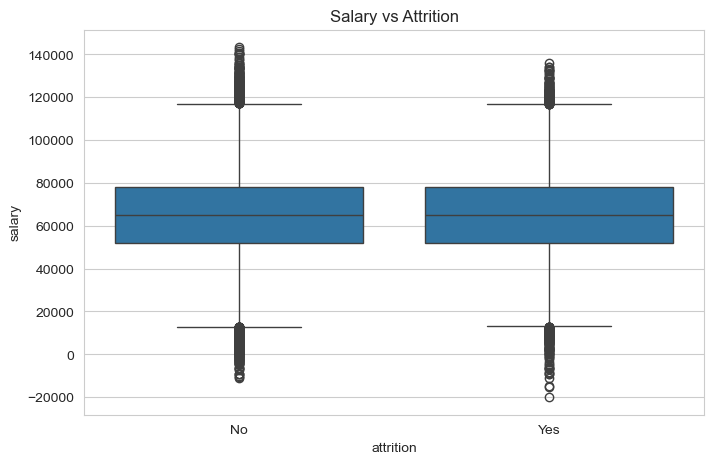

In [238]:
plt.figure(figsize=(8,5))

sns.boxplot(x="attrition", y="salary", data=clean_df)

plt.title("Salary vs Attrition")

plt.show()

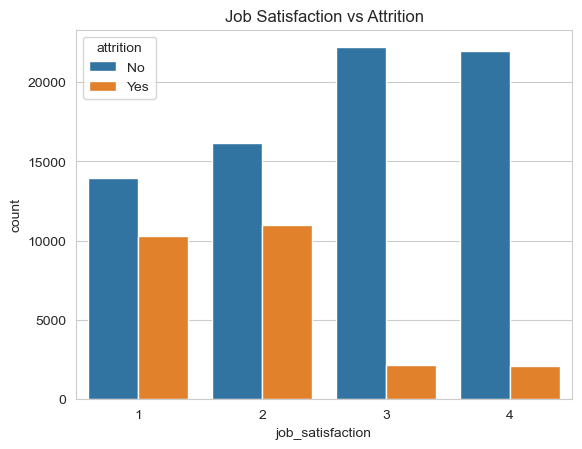

In [239]:
sns.countplot(x="job_satisfaction", hue="attrition", data=clean_df)

plt.title("Job Satisfaction vs Attrition")

plt.show()

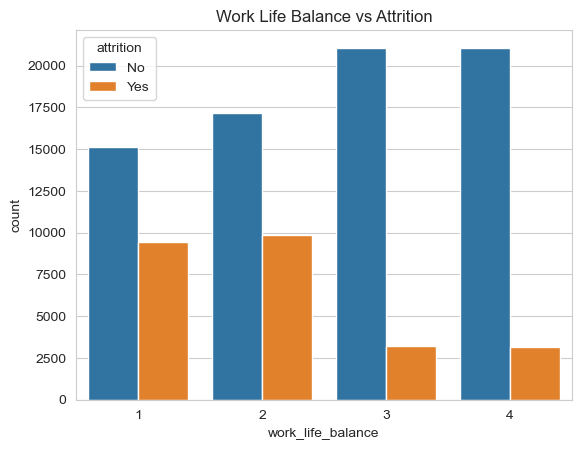

In [240]:
sns.countplot(x="work_life_balance", hue="attrition", data=clean_df)

plt.title("Work Life Balance vs Attrition")

plt.show()

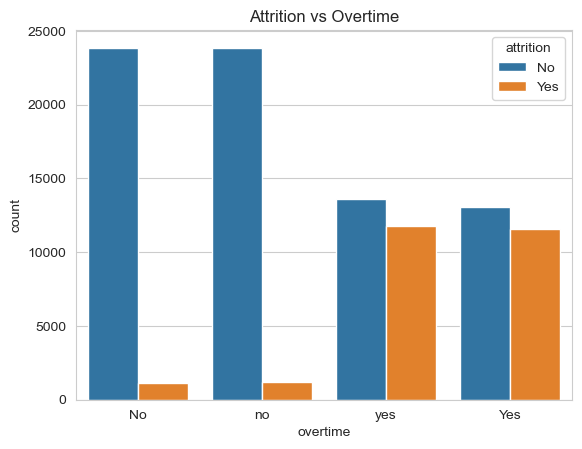

In [241]:
sns.countplot(x='overtime', hue='attrition', data=clean_df)

plt.title("Attrition vs Overtime")

plt.show()

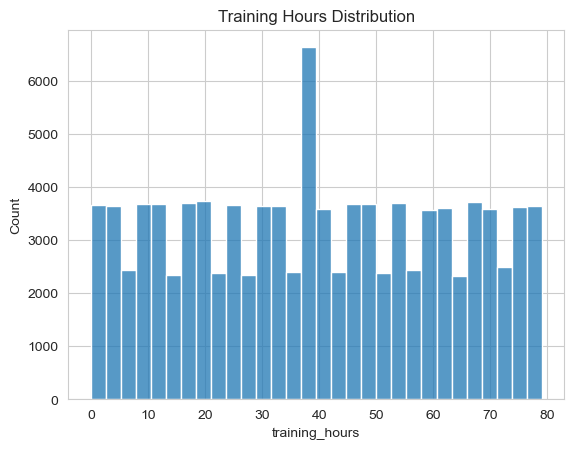

In [242]:
sns.histplot(clean_df["training_hours"], bins=30)

plt.title("Training Hours Distribution")

plt.show()

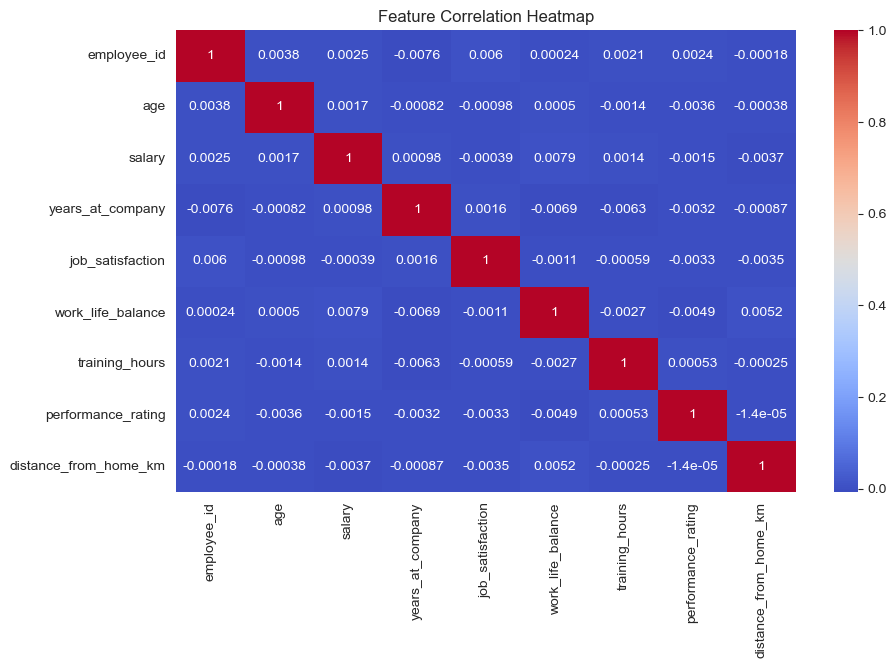

In [243]:
plt.figure(figsize=(10,6))

sns.heatmap(clean_df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [244]:
clean_df.describe()


,employee_id,age,salary,years_at_company,job_satisfaction,work_life_balance,training_hours,performance_rating,distance_from_home_km
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,149999.500000,40.058210,65010.888577,19.511980,2.483010,2.48149,39.427950,2.503590,24.902260
std,28867.657797,11.243079,19725.346499,11.549876,1.103668,1.10700,22.766984,1.118302,14.147517
min,100000.000000,21.000000,-20027.000000,0.000000,1.000000,1.00000,0.000000,1.000000,1.000000
25%,124999.750000,30.000000,51985.750000,9.000000,2.000000,2.00000,20.000000,2.000000,13.000000
50%,149999.500000,40.000000,65010.888580,20.000000,2.000000,2.00000,39.000000,3.000000,25.000000
75%,174999.250000,50.000000,78006.250000,30.000000,3.000000,3.00000,59.000000,4.000000,37.000000
max,199999.000000,59.000000,143363.000000,39.000000,4.000000,4.00000,79.000000,4.000000,49.000000


In [245]:
"""ML"""
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

clean_df['gender'] = le.fit_transform(clean_df['gender'])
clean_df['department'] = le.fit_transform(clean_df['department'])
clean_df['job_role'] = le.fit_transform(clean_df['job_role'])
clean_df['education_field'] = le.fit_transform(clean_df['education_field'])

In [246]:
clean_df['attrition'] = clean_df['attrition'].map({'Yes':1, 'No':0})
"""(change char(txt) to numerical) now yes = 1 and no = 0"""

'(change char(txt) to numerical) now yes = 1 and no = 0'

In [247]:
clean_df['overtime'] = clean_df['overtime'].map({'yes':1, 'no':0})

In [248]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   employee_id            100000 non-null  int64  
 1   age                    100000 non-null  int64  
 2   gender                 100000 non-null  int64  
 3   department             100000 non-null  int64  
 4   job_role               100000 non-null  int64  
 5   education_field        100000 non-null  int64  
 6   salary                 100000 non-null  float64
 7   years_at_company       100000 non-null  int64  
 8   job_satisfaction       100000 non-null  int64  
 9   work_life_balance      100000 non-null  int64  
 10  training_hours         100000 non-null  int64  
 11  performance_rating     100000 non-null  int64  
 12  distance_from_home_km  100000 non-null  int64  
 13  overtime               50366 non-null   float64
 14  attrition              100000 non-nul

In [249]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [250]:
"""X = input features y = prediction target"""
clean_df = clean_df.drop('employee_id', axis=1)


In [251]:
X = clean_df.drop('attrition', axis=1)
y = clean_df['attrition']

In [252]:
"""train model"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [253]:
clean_df.isnull().sum()

age                          0
gender                       0
department                   0
job_role                     0
education_field              0
salary                       0
years_at_company             0
job_satisfaction             0
work_life_balance            0
training_hours               0
performance_rating           0
distance_from_home_km        0
overtime                 49634
attrition                    0
dtype: int64

In [254]:
clean_df['overtime'] = clean_df['overtime'].fillna(clean_df['overtime'].mode()[0])

In [255]:
"""model.fit(X_train, y_train)"""
clean_df.isnull().sum()

age                      0
gender                   0
department               0
job_role                 0
education_field          0
salary                   0
years_at_company         0
job_satisfaction         0
work_life_balance        0
training_hours           0
performance_rating       0
distance_from_home_km    0
overtime                 0
attrition                0
dtype: int64

In [256]:
X.isnull().sum()

age                          0
gender                       0
department                   0
job_role                     0
education_field              0
salary                       0
years_at_company             0
job_satisfaction             0
work_life_balance            0
training_hours               0
performance_rating           0
distance_from_home_km        0
overtime                 49634
dtype: int64

In [257]:
X_train.isnull().sum()

age                          0
gender                       0
department                   0
job_role                     0
education_field              0
salary                       0
years_at_company             0
job_satisfaction             0
work_life_balance            0
training_hours               0
performance_rating           0
distance_from_home_km        0
overtime                 39665
dtype: int64

In [258]:
X = clean_df.drop('attrition', axis=1)
y = clean_df['attrition']

In [259]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [260]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [261]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000, solver='lbfgs')
model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [262]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7958


In [263]:
"""models"""

'models'

In [264]:
"""1. Decision tree"""
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)

In [265]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [266]:
y_pred_dt = dt_model.predict(X_test)

In [267]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7446


In [268]:
"""2. random forest"""
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [269]:
"""100 trees → each makes prediction Final prediction → majority vote"""

'100 trees → each makes prediction\n   Final prediction → majority vote'

In [270]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [271]:
y_pred_rf = rf_model.predict(X_test)

In [272]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.82295


In [273]:
"""feature importance"""
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                  Feature  Importance
7        job_satisfaction    0.162071
5                  salary    0.105924
8       work_life_balance    0.100142
12               overtime    0.093970
9          training_hours    0.089898
11  distance_from_home_km    0.083778
6        years_at_company    0.083574
0                     age    0.081601
2              department    0.052815
3                job_role    0.048923
4         education_field    0.041428
10     performance_rating    0.032295
1                  gender    0.023580


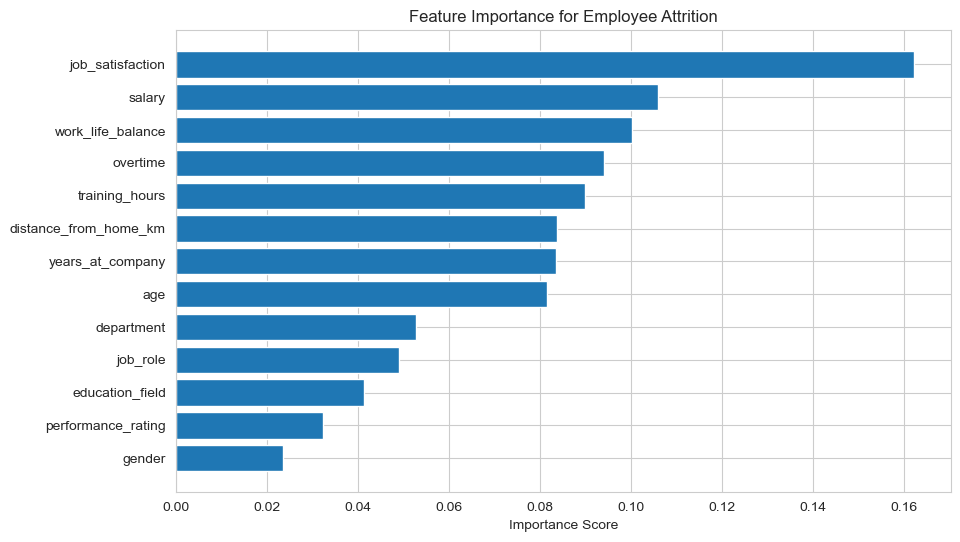

In [274]:
"""why emp leave"""
import matplotlib.pyplot as plt
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance for Employee Attrition")
plt.xlabel("Importance Score")
plt.show()

In [275]:
"""confusion matrix"""
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[13635  1242]
 [ 2299  2824]]


In [278]:
"""13k = stayed employee correct prediction, 1242= stayed but pridiction is leaving
   2299 = predic is stay but left , 2824 =left correct pred  """

'13k = stayed employee correct prediction, 1242= stayed but pridiction is leaving\n   2299 = predic is stay but left , 2824 =left correct pred  '

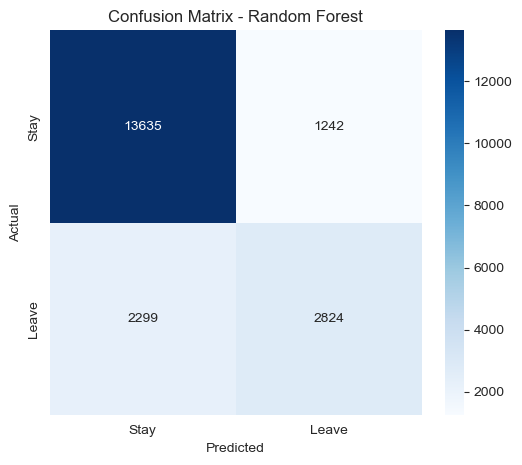

In [277]:
"""visual"""
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Stay','Leave'],
            yticklabels=['Stay','Leave'])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [281]:
"""PREDICTION SYSTEM"""

import pandas as pd

new_employee = pd.DataFrame([{
    'age': 35,
    'gender': 1,
    'department': 2,
    'job_role': 3,
    'education_field': 1,
    'salary': 50000,
    'years_at_company': 5,
    'job_satisfaction': 2,
    'work_life_balance': 3,
    'training_hours': 20,
    'performance_rating': 3,
    'distance_from_home_km': 10,
    'overtime': 1
}])
prediction = rf_model.predict(new_employee.values)

print(prediction)

if prediction[0] == 1:
    print("Prediction: Employee Likely To Leave")
else:
    print("Prediction: Employee Likely To Stay")

[0]
Prediction: Employee Likely To Stay


In [283]:
"""ROC curve"""
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
y_prob = rf_model.predict_proba(X_test)[:,1]

In [285]:
"""FPR = False Positive Rate ,TPR = True Positive Rate ,thresholds = decision boundaries"""
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [286]:
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

AUC Score: 0.861741181717673


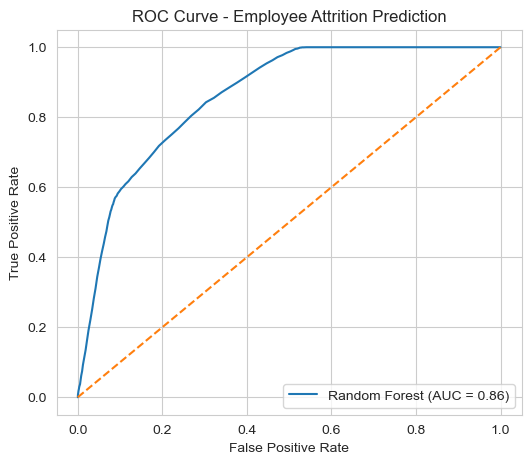

In [287]:
"""curve"""
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Random Forest (AUC = %.2f)" % auc_score)

plt.plot([0,1],[0,1],'--')  # random prediction line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Employee Attrition Prediction")
plt.legend()

plt.show()